In [18]:
import pandas as pd
import matplotlib.pyplot as plt


In [19]:
df = pd.read_csv("/content/ecommerce_order_delivery_python.csv")


In [20]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])
df['delivery_date'] = pd.to_datetime(df['delivery_date'])


In [21]:
# Delivery time
df['delivery_days'] = (df['delivery_date'] - df['ship_date']).dt.days


In [22]:
# Delay flag
df['is_delayed'] = df['delivery_days'] > 5


In [23]:
df['month'] = df['order_date'].dt.to_period('M').astype(str)

print(df.head())

  order_id customer_id order_date  ship_date delivery_date product_id  \
0  O000001      C00229 2023-01-26 2023-01-28    2023-02-02      P0053   
1  O000002      C00448 2023-08-27 2023-08-27    2023-09-06      P0280   
2  O000003      C00327 2024-12-15 2024-12-18    2024-12-25      P0111   
3  O000004      C00542 2023-02-14 2023-02-17    2023-02-27      P0194   
4  O000005      C00143 2023-02-16 2023-02-17    2023-02-23      P0120   

         category  order_amount  quantity    payment_method order_status  \
0       Groceries       3086.53         5  Cash on Delivery    Completed   
1          Beauty       4712.41         2        Debit Card    Completed   
2  Home & Kitchen        645.18         1               UPI    Completed   
3     Electronics       8036.28         5       Net Banking    Completed   
4     Electronics       6137.09         4        Debit Card    Completed   

  delivery_status       city        state  pincode  shipping_cost  \
0         On Time  Hyderabad    Tel

Average Delivery Time: 5.92 days


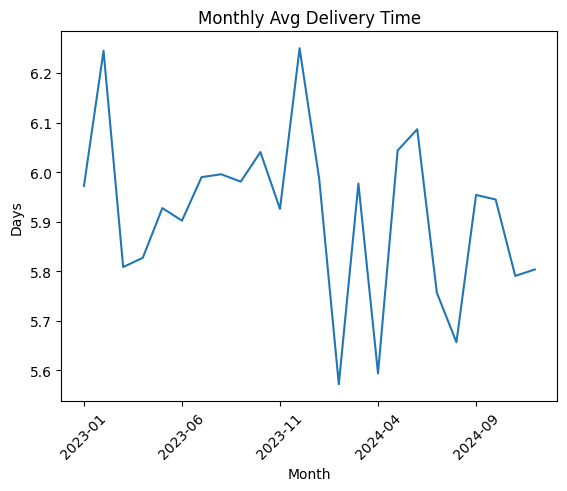

In [24]:
# Delivery Time Analysis
avg_delivery = df['delivery_days'].mean()
print("Average Delivery Time:", round(avg_delivery, 2), "days")

monthly_delivery = df.groupby('month')['delivery_days'].mean()

plt.figure()
monthly_delivery.plot(kind='line')
plt.title("Monthly Avg Delivery Time")
plt.xlabel("Month")
plt.ylabel("Days")
plt.xticks(rotation=45)
plt.show()


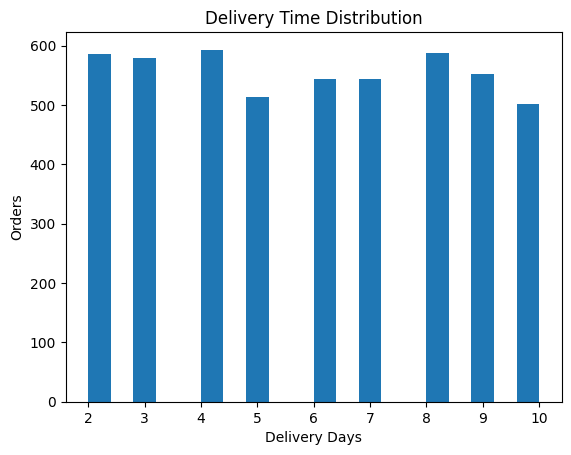

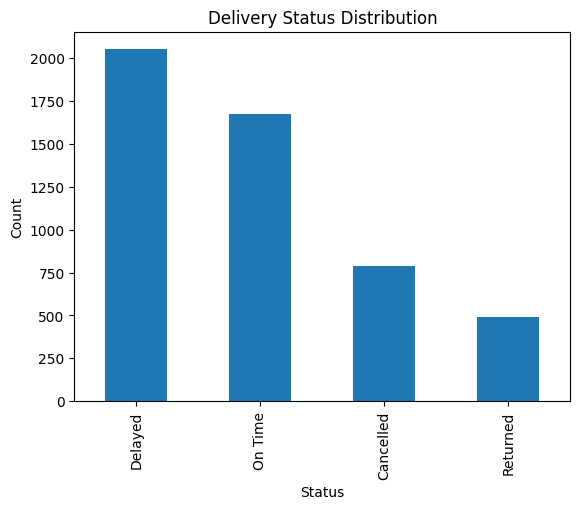

In [34]:
# Delay Distribution
plt.figure()
df['delivery_days'].plot(kind='hist', bins=20)
plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Orders")
plt.show()

plt.figure()
df['delivery_status'].value_counts().plot(kind='bar')
plt.title("Delivery Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()


Category Performance:
 category
Beauty            5.713253
Books             5.762399
Home & Kitchen    5.907204
Electronics       6.015330
Fashion           6.055422
Groceries         6.081886
Name: delivery_days, dtype: float64


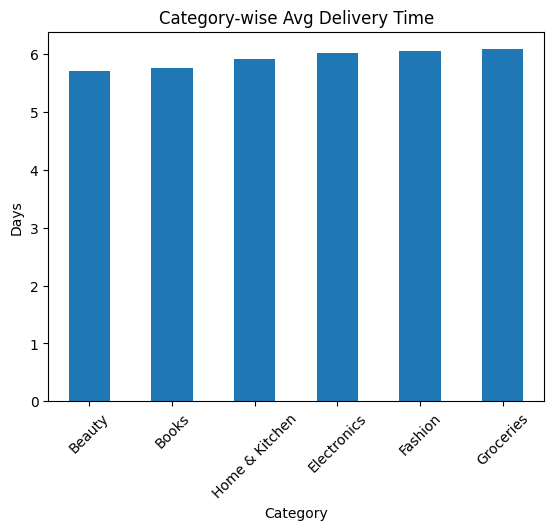

In [27]:
# Category wise performance
category_perf = df.groupby('category')['delivery_days'].mean().sort_values()

print("\nCategory Performance:\n", category_perf)

plt.figure()
category_perf.plot(kind='bar')
plt.title("Category-wise Avg Delivery Time")
plt.xlabel("Category")
plt.ylabel("Days")
plt.xticks(rotation=45)
plt.show()


City Performance:
 city
Hyderabad        5.734277
Pune             5.823248
Mumbai           5.849026
Kolkata          5.929260
Chennai          5.934959
Bengaluru        5.953411
Visakhapatnam    5.993994
Delhi            6.152597
Name: delivery_days, dtype: float64


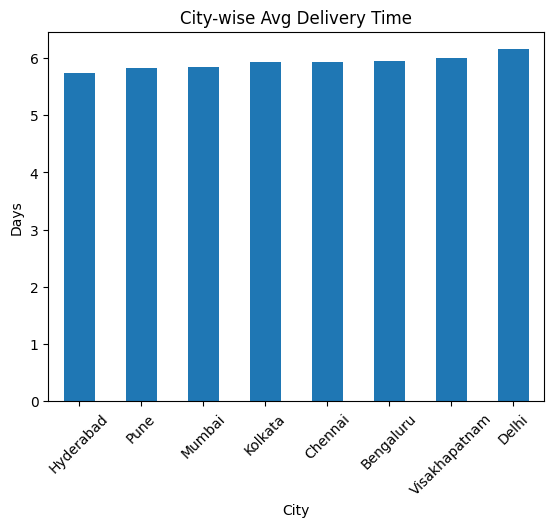

In [28]:
# City wise analysis
city_perf = df.groupby('city')['delivery_days'].mean().sort_values()

print("\nCity Performance:\n", city_perf)

plt.figure()
city_perf.plot(kind='bar')
plt.title("City-wise Avg Delivery Time")
plt.xlabel("City")
plt.ylabel("Days")
plt.xticks(rotation=45)
plt.show()



SLA Met %: 45.42


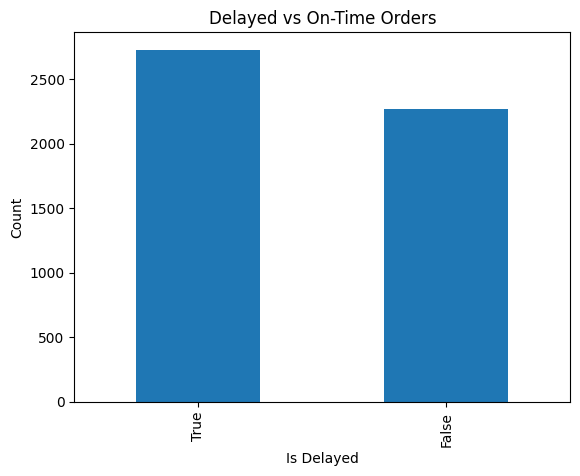

In [29]:
# SLA analysis
sla_met = (df['delivery_days'] <= 5).sum()
total_orders = len(df)

print("\nSLA Met %:", round((sla_met/total_orders)*100, 2))

plt.figure()
df['is_delayed'].value_counts().plot(kind='bar')
plt.title("Delayed vs On-Time Orders")
plt.xlabel("Is Delayed")
plt.ylabel("Count")
plt.show()


Delivery Buckets:
 delivery_bucket
Very Slow    1641
Fast         1164
Normal       1107
Slow         1088
Name: count, dtype: int64


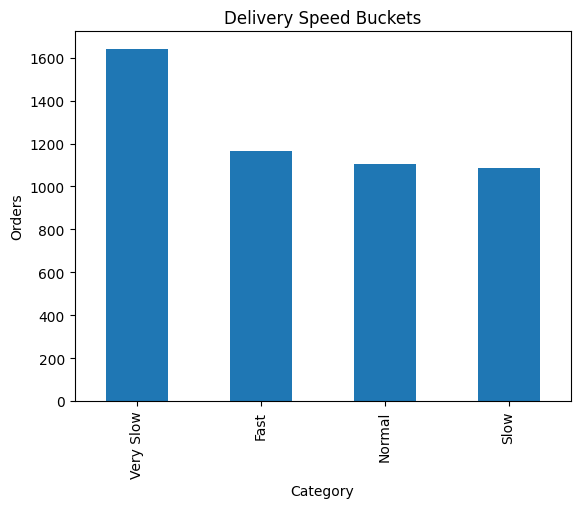

In [30]:
# Delivery bucket analysis
df['delivery_bucket'] = pd.cut(
    df['delivery_days'],
    bins=[0,3,5,7,10],
    labels=['Fast','Normal','Slow','Very Slow']
)

bucket_counts = df['delivery_bucket'].value_counts()

print("\nDelivery Buckets:\n", bucket_counts)

plt.figure()
bucket_counts.plot(kind='bar')
plt.title("Delivery Speed Buckets")
plt.xlabel("Category")
plt.ylabel("Orders")
plt.show()

In [31]:
# Top delayed analysis
top_delays = df.sort_values(by='delivery_days', ascending=False).head(10)

print("\nTop Delayed Orders:\n")
print(top_delays[['order_id','city','category','delivery_days']])



Top Delayed Orders:

     order_id           city     category  delivery_days
3     O000004        Kolkata  Electronics             10
4996  O004997          Delhi  Electronics             10
9     O000010          Delhi  Electronics             10
4982  O004983        Chennai    Groceries             10
1688  O001689          Delhi        Books             10
1618  O001619  Visakhapatnam      Fashion             10
1626  O001627        Chennai  Electronics             10
1627  O001628        Chennai  Electronics             10
1632  O001633      Hyderabad  Electronics             10
4894  O004895        Kolkata      Fashion             10


In [32]:
# Revenue impact
delayed_revenue = df[df['is_delayed']]['order_amount'].sum()
total_revenue = df['order_amount'].sum()

print("\nRevenue from Delayed Orders %:",
      round((delayed_revenue/total_revenue)*100, 2))



Revenue from Delayed Orders %: 55.17
